# Semantic Similarity Analysis

This notebook explores cosine similarity, BERTScore, and ROUGE-L for each paired human and AI answer.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED = PROJECT_ROOT / 'data' / 'processed'
scores = pd.read_csv(PROCESSED / 'semantic_similarity_scores.csv')
summary = pd.read_csv(PROCESSED / 'semantic_similarity_summary.csv')
metric_columns = ['cosine_similarity', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1', 'rougeL_precision', 'rougeL_recall', 'rougeL_f1']
print(f'Pairs scored: {len(scores):,}')
display(scores.head())

Pairs scored: 30


,row_number,Person ID,Question Category,Question Text,cosine_similarity,model_name,bertscore_precision,bertscore_recall,bertscore_f1,rougeL_precision,rougeL_recall,rougeL_f1
0,2,c_human,shopping behavior,where do you typically purchase your personal ...,0.678975,sentence-transformers/all-mpnet-base-v2,0.853883,0.878083,0.865814,0.129630,0.241379,0.168675
1,3,s_human,shopping behavior,where do you typically purchase your personal ...,0.820332,sentence-transformers/all-mpnet-base-v2,0.860475,0.888672,0.874346,0.118644,0.205882,0.150538
2,4,g_human,shopping behavior,where do you typically purchase your personal ...,0.803594,sentence-transformers/all-mpnet-base-v2,0.880564,0.876279,0.878416,0.250000,0.250000,0.250000
3,5,c_human,product preferences,which personal care brands do you buy most oft...,0.570638,sentence-transformers/all-mpnet-base-v2,0.855422,0.899210,0.876770,0.098039,0.263158,0.142857
4,6,s_human,product preferences,which personal care brands do you buy most oft...,0.855700,sentence-transformers/all-mpnet-base-v2,0.850332,0.921333,0.884410,0.171875,0.578947,0.265060


## Overall Score Summary

,metric,count,mean,std,min,50%,max
0,cosine_similarity,30,0.585,0.181,0.157,0.617,0.856
1,bertscore_precision,30,0.844,0.020,0.788,0.845,0.881
2,bertscore_recall,30,0.868,0.024,0.828,0.866,0.921
3,bertscore_f1,30,0.856,0.018,0.821,0.856,0.884
4,rougeL_precision,30,0.126,0.051,0.042,0.125,0.250
5,rougeL_recall,30,0.248,0.141,0.077,0.198,0.600
6,rougeL_f1,30,0.153,0.055,0.066,0.147,0.265


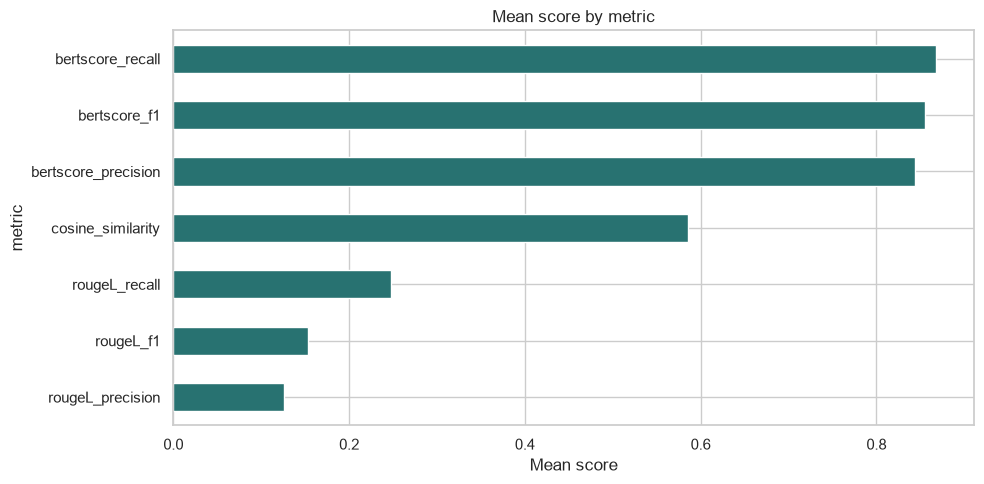

In [2]:
overall = summary[summary['group_type'] == 'overall'].copy()
display(overall[['metric', 'count', 'mean', 'std', 'min', '50%', 'max']].round(3))
overall_plot = overall.set_index('metric')['mean'].sort_values()
overall_plot.plot(kind='barh', figsize=(10, 5), color='#287271')
plt.title('Mean score by metric')
plt.xlabel('Mean score')
plt.tight_layout()

## Score Distributions

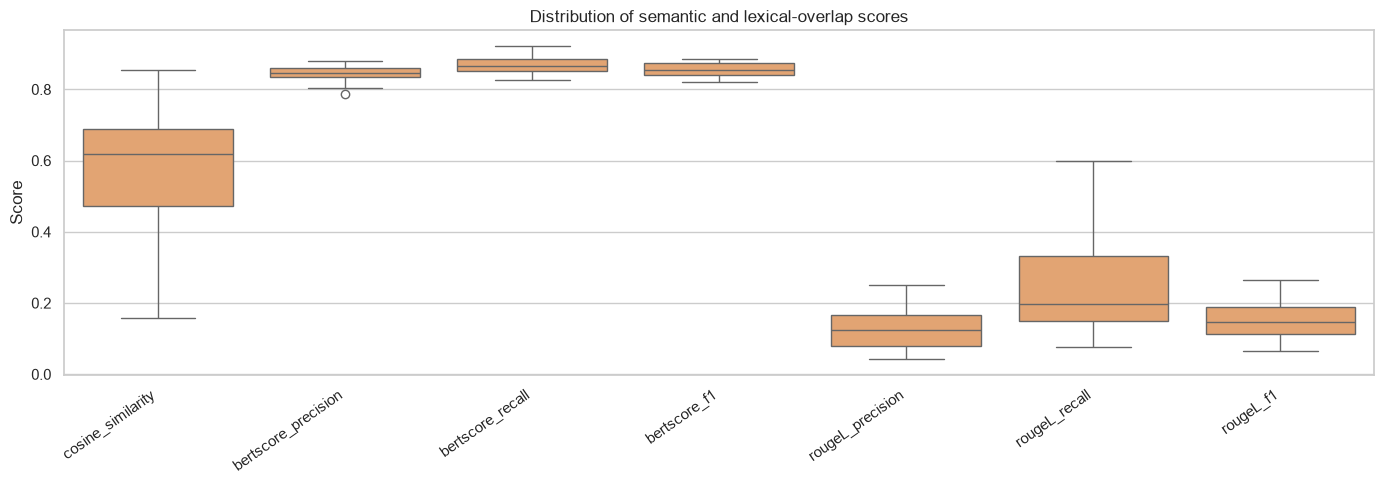

In [3]:
long_scores = scores.melt(id_vars=['Question Category'], value_vars=metric_columns, var_name='metric', value_name='score')
plt.figure(figsize=(14, 5))
sns.boxplot(data=long_scores, x='metric', y='score', color='#f4a261')
plt.title('Distribution of semantic and lexical-overlap scores')
plt.ylabel('Score')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

## Question-Category Comparisons

,cosine_similarity,bertscore_precision,bertscore_recall,bertscore_f1,rougeL_precision,rougeL_recall,rougeL_f1
Question Category,,,,,,,
brand loyalty,0.668,0.851,0.876,0.863,0.135,0.302,0.177
product preferences,0.616,0.845,0.872,0.858,0.133,0.275,0.161
shopping behavior,0.585,0.846,0.870,0.857,0.130,0.240,0.157
influences,0.351,0.830,0.830,0.830,0.067,0.080,0.072


<Figure size 1200x500 with 0 Axes>

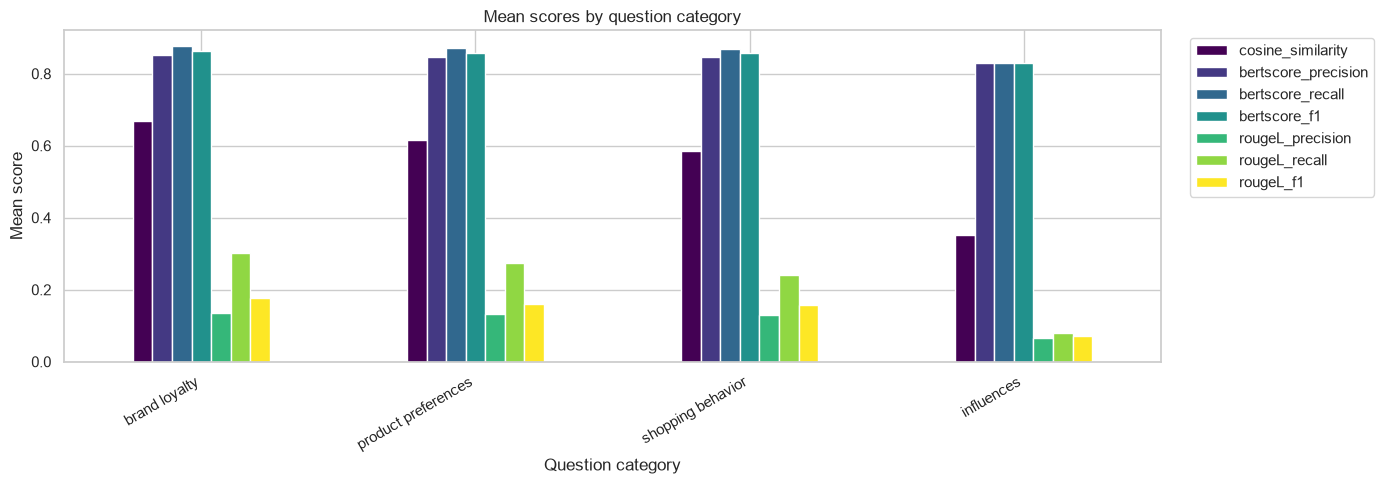

In [4]:
category_means = (scores.groupby('Question Category')[metric_columns].mean().sort_values('cosine_similarity', ascending=False))
display(category_means.round(3))
plt.figure(figsize=(12, 5))
category_means.plot(kind='bar', figsize=(14, 5), colormap='viridis')
plt.title('Mean scores by question category')
plt.ylabel('Mean score')
plt.xlabel('Question category')
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

## Metric Agreement

,cosine_similarity,bertscore_precision,bertscore_recall,bertscore_f1,rougeL_precision,rougeL_recall,rougeL_f1
cosine_similarity,1.000,0.838,0.552,0.841,0.724,0.002,0.738
bertscore_precision,0.838,1.000,0.344,0.804,0.762,-0.238,0.675
bertscore_recall,0.552,0.344,1.000,0.834,0.301,0.637,0.589
bertscore_f1,0.841,0.804,0.834,1.000,0.635,0.262,0.769
rougeL_precision,0.724,0.762,0.301,0.635,1.000,-0.001,0.877
rougeL_recall,0.002,-0.238,0.637,0.262,-0.001,1.000,0.377
rougeL_f1,0.738,0.675,0.589,0.769,0.877,0.377,1.000


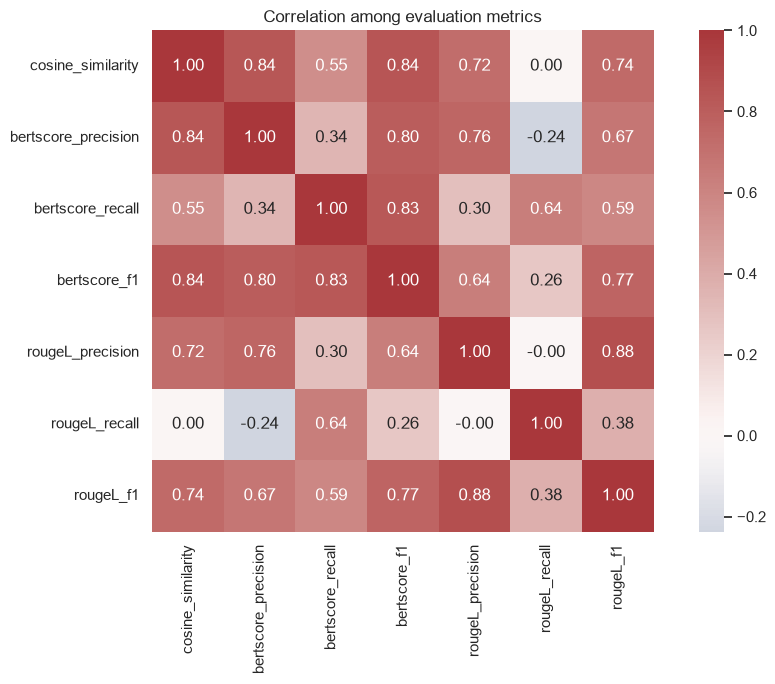

In [5]:
correlations = scores[metric_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0, square=True)
plt.title('Correlation among evaluation metrics')
plt.tight_layout()
display(correlations.round(3))

## Outlier Inspection

In [6]:
lowest = scores.nsmallest(5, 'cosine_similarity')[['row_number', 'Person ID', 'Question Category'] + metric_columns]
highest = scores.nlargest(5, 'cosine_similarity')[['row_number', 'Person ID', 'Question Category'] + metric_columns]
print('Lowest cosine-similarity pairs')
display(lowest.round(3))
print('Highest cosine-similarity pairs')
display(highest.round(3))
print('Interpretation: embedding scores capture semantic relatedness, BERTScore captures contextual token alignment, and ROUGE-L captures ordered overlap. Use them together rather than treating one score as definitive.')

Lowest cosine-similarity pairs


,row_number,Person ID,Question Category,cosine_similarity,bertscore_precision,bertscore_recall,bertscore_f1,rougeL_precision,rougeL_recall,rougeL_f1
27,29,c_human,shopping behavior,0.157,0.803,0.840,0.821,0.050,0.455,0.089
13,15,s_human,influences,0.217,0.821,0.833,0.827,0.062,0.086,0.072
21,23,c_human,product preferences,0.243,0.788,0.894,0.838,0.042,0.600,0.078
28,30,s_human,shopping behavior,0.390,0.829,0.840,0.835,0.065,0.148,0.090
12,14,c_human,influences,0.413,0.838,0.828,0.833,0.057,0.077,0.066


Highest cosine-similarity pairs


,row_number,Person ID,Question Category,cosine_similarity,bertscore_precision,bertscore_recall,bertscore_f1,rougeL_precision,rougeL_recall,rougeL_f1
4,6,s_human,product preferences,0.856,0.850,0.921,0.884,0.172,0.579,0.265
1,3,s_human,shopping behavior,0.820,0.860,0.889,0.874,0.119,0.206,0.151
16,18,s_human,product preferences,0.810,0.865,0.876,0.871,0.188,0.250,0.214
2,4,g_human,shopping behavior,0.804,0.881,0.876,0.878,0.250,0.250,0.250
7,9,s_human,product preferences,0.792,0.861,0.903,0.882,0.163,0.381,0.229


Interpretation: embedding scores capture semantic relatedness, BERTScore captures contextual token alignment, and ROUGE-L captures ordered overlap. Use them together rather than treating one score as definitive.
